## 각 데이터셋별로 train, validation, test 데이터셋 분리 (user_id 기준)

In [86]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

def tr_val_test_split(df):
    # 1개 이하만 존재하는 클래스는 train set에 포함
    class_counts = df['label'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    stratify_df = df[df['label'].isin(valid_classes)]

    rare_df = df[~df['label'].isin(valid_classes)]

    train_df, tmp_df = train_test_split(stratify_df, test_size=0.2, random_state=42, stratify=stratify_df['label'])
    train_df = pd.concat([train_df, rare_df], ignore_index=True)

    try:
        val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['label'], random_state=42)
    except ValueError as e:
        tmp_class_counts = tmp_df['label'].value_counts()
        tmp_valid_classes = tmp_class_counts[tmp_class_counts >= 2].index
        tmp_stratify_df = tmp_df[tmp_df['label'].isin(tmp_valid_classes)]

        tmp_rare_df = tmp_df[~tmp_df['label'].isin(tmp_valid_classes)]

        val_df, test_df = train_test_split(tmp_stratify_df, test_size=0.2, random_state=42, stratify=tmp_stratify_df['label'])
        val_df = pd.concat([val_df, tmp_rare_df], ignore_index=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    counts = [train_df['label'].value_counts().sort_index(), val_df.value_counts('label').sort_index(), test_df.value_counts('label').sort_index()]
    
    for i, ax in enumerate(axes):
        counts[i].plot(kind='bar', ax=ax)
        ax.set_title(['Train', 'Validation', 'Test'][i])
        ax.set_xlabel('label')
        ax.set_ylabel('count')
    plt.tight_layout()
    
    plt.show()

    return train_df, val_df, test_df

### 117_data

In [145]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/117_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'pig_label_paths.json'), orient='records', dtype={'user_id':str, })
origin_df['label'] = origin_df.apply(lambda x:x['left_label'] if x['left_label'] == -1 else x['right_label'], axis=1)

user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
check = len(user_split['user_id']) == len(user_split['user_id'].unique())
print(f"user_id가 unique하게 존재하는가???? : {check}")
if not check:
    print(user_split['label'].value_counts())
    ## label의 max값으로 unique하게 만들기
    user_split = user_split.sort_values(by='label', ascending=False).drop_duplicates(subset=['user_id'], ignore_index=True)

user_id가 unique하게 존재하는가???? : False
label
 0    264
 1    229
 2    117
 3     33
 4      4
-1      1
Name: count, dtype: int64


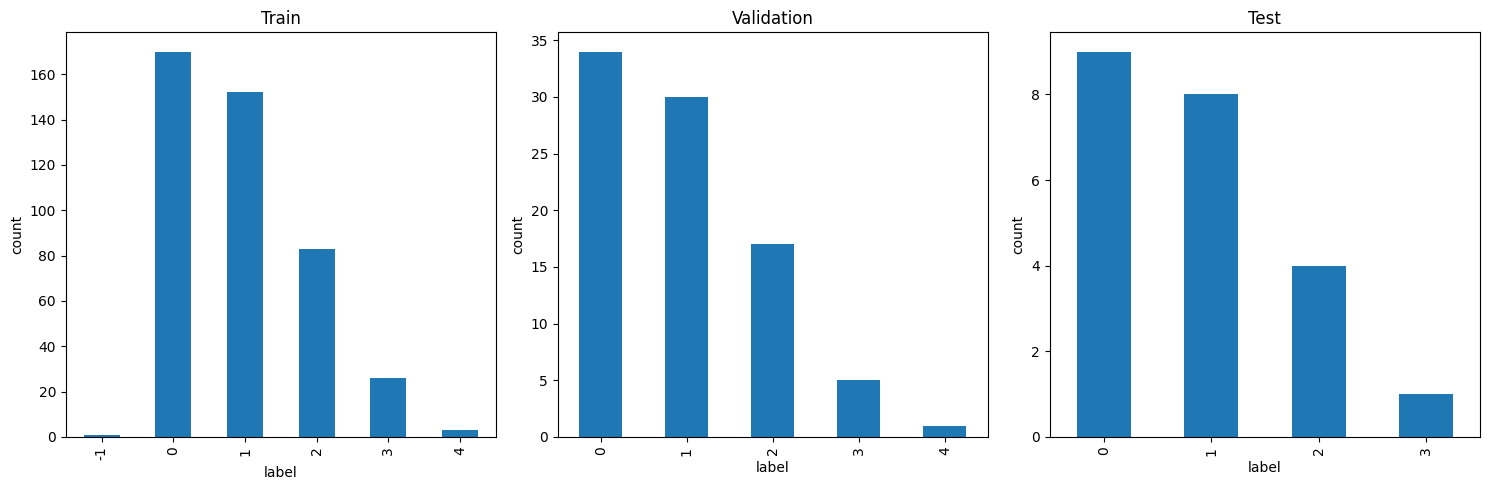

In [146]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [147]:
# 4번 그냥 적은거. left 기준이긴 함
train_df['label'].value_counts(), val_df['label'].value_counts(), test_df['label'].value_counts()

(label
  0    170
  1    152
  2     83
  3     26
  4      3
 -1      1
 Name: count, dtype: int64,
 label
 0    34
 1    30
 2    17
 3     5
 4     1
 Name: count, dtype: int64,
 label
 0    9
 1    8
 2    4
 3    1
 Name: count, dtype: int64)

In [148]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])

In [149]:
split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

In [152]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)